In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


In [9]:
np.random.seed(42)

In [10]:
X = np.linspace(0, 6, 100).reshape(-1, 1)
y = 2 * X**2 - 5 * X + 3 + np.random.randn(100, 1) * 3

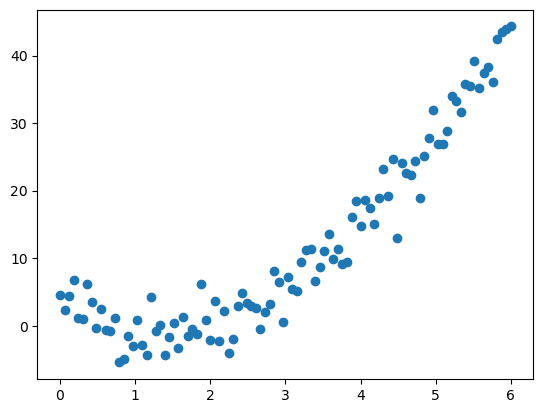

In [11]:
plt.scatter(X,y)

In [12]:
poly=PolynomialFeatures(degree=2)

In [13]:
X_poly=poly.fit_transform(X)

In [15]:
X_poly.shape

(100, 3)

In [16]:
X_poly[:3]

array([[1.        , 0.        , 0.        ],
       [1.        , 0.06060606, 0.00367309],
       [1.        , 0.12121212, 0.01469238]])

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

In [18]:
model=LinearRegression()

In [19]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

In [28]:
r2_score(y_train,y_pred_train)

0.9619042014641127

In [29]:
r2_score(y_test,y_pred_test)

0.9608449902108023

In [30]:
degrees = [1, 2, 5, 10]
colors = ['red', 'green', 'orange', 'purple']

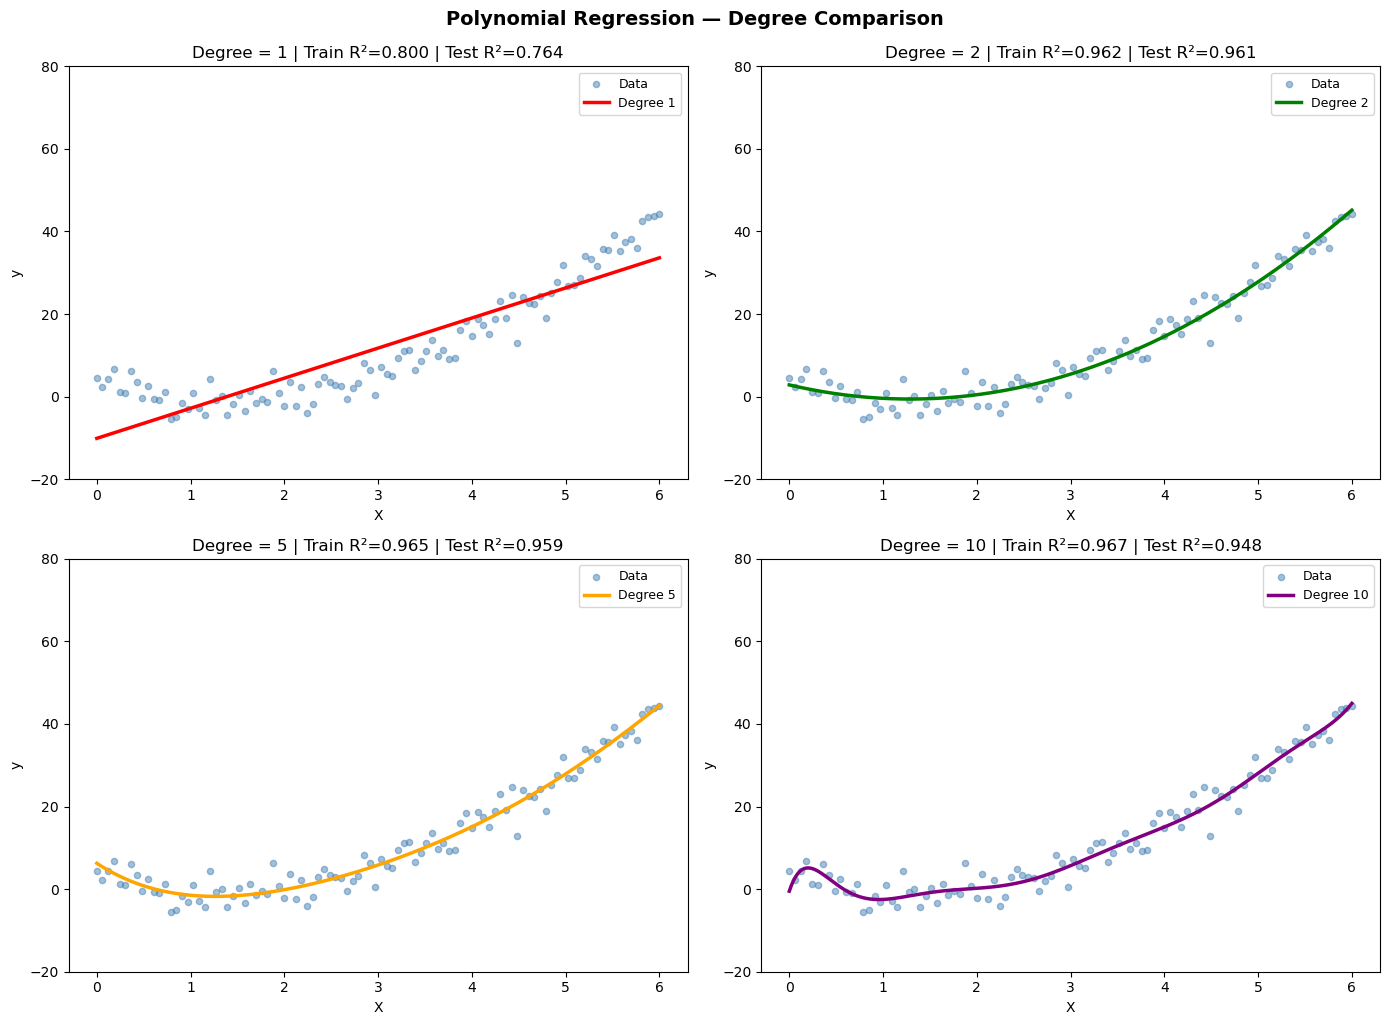

In [31]:
plt.figure(figsize=(14, 10))

for i, (deg, color) in enumerate(zip(degrees, colors)):
    
    # Har degree ke liye polynomial features banao
    poly = PolynomialFeatures(degree=deg)
    X_poly = poly.fit_transform(X)
    
    # Train-Test split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_poly, y, test_size=0.2, random_state=42
    )
    
    # Model train karo
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    
    # Smooth curve ke liye 300 points
    X_smooth = np.linspace(0, 6, 300).reshape(-1, 1)
    X_smooth_poly = poly.transform(X_smooth)
    y_smooth = model.predict(X_smooth_poly)
    
    # Scores nikalo
    train_r2 = r2_score(y_tr, model.predict(X_tr))
    test_r2  = r2_score(y_te, model.predict(X_te))
    
    # Plot
    plt.subplot(2, 2, i+1)
    plt.scatter(X, y, color='steelblue', alpha=0.5, s=20, label='Data')
    plt.plot(X_smooth, y_smooth, color=color, linewidth=2.5,
             label=f'Degree {deg}')
    plt.title(f'Degree = {deg} | Train R²={train_r2:.3f} | Test R²={test_r2:.3f}')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.ylim(-20, 80)
    plt.legend(fontsize=9)

plt.tight_layout()
plt.suptitle('Polynomial Regression — Degree Comparison', 
             y=1.02, fontsize=14, fontweight='bold')
plt.show()

In [32]:
print(f"{'Degree':<10} {'Train R²':<15} {'Test R²':<15}")
print("-" * 40)

for deg in [1, 2, 3, 5, 10]:
    poly = PolynomialFeatures(degree=deg)
    X_poly = poly.fit_transform(X)
    
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_poly, y, test_size=0.2, random_state=42
    )
    
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    
    train_r2 = r2_score(y_tr, model.predict(X_tr))
    test_r2  = r2_score(y_te, model.predict(X_te))
    
    print(f"{deg:<10} {train_r2:<15.4f} {test_r2:<15.4f}")

Degree     Train R²        Test R²        
----------------------------------------
1          0.7998          0.7636         
2          0.9619          0.9608         
3          0.9639          0.9619         
5          0.9647          0.9590         
10         0.9668          0.9484         


In [33]:
from sklearn.pipeline import Pipeline

In [34]:
pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2)),
    ('linear_reg',    LinearRegression())
])

In [35]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
pipeline.fit(X_train_raw,y_train_raw)

,steps,"[('poly_features', ...), ('linear_reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [37]:
y_pred_pipeline=pipeline.predict(X_test_raw)

In [38]:
r2_score(y_test_raw,y_pred_pipeline)

0.9608449902108023